# **Applied Data Science in Medicine & Psychology - Assignment 8**
## Statistics
---
**Deadline: 04.07.2023, 23:59**
### **General setup and submission**
1. Save an editable copy of this notebook to your Google Drive ``File`` $\rightarrow$ ``Save a copy in Drive`` and remove the automatically appended "Copy of" text. **Do not change the file name**.
2. Work on the assignment in the *copied* version of the notebook. Make sure that you **replace** all parts of the tasks indicated with *YOUR CODE HERE* and **raise NotImplementedError()** (otherwise this causes an error in your implementation) or *YOUR ANSWER HERE* with your solution.
3. If you take a break during the implementation, you can save the current status of your work in your repository following the submission instructions below. When you continue working on the assignment, do this in the version of the notebook that you saved in your Google Drive (access from your Google Colab account) or your repository.
4. After finishing the assignment submit your assignment as follows:
    * Check that everything runs as expected. To do that select in the menubar ``Runtime`` $\rightarrow$ ``Restart and run all``. This will clear all your local variables and runs your notebook from the beginning
    * Save your notebook, click ``File`` $\rightarrow$ ``Save``
    * Click ``File`` $\rightarrow$ ``Save a copy in GitHub``
    * Select ``digikolleg-data-science-psychology/08_statistics-<username>`` from the Repository drop-down menu 
    * Type ``08_statistics.ipynb`` into the File path text box
    * Optionally, you may enter a description into the "Commit message" text box (like: "solved task 1" or "ready for grading")
    * Make sure that the "Include a link to Colaboratory" box is checked
    * Press "Ok"
    * A new tab or window should open up, displaying your submitted notebook within your GitHub repository

Before the assignment deadline, you can re-submit your assignment as often as you would like. This will update the copy of your assignment file in your assignment's repository.

### **Assignment Description**
***General description... TODO***

#### **Assignment goals**
You are going to learn the following things in this assignment:
1. ***TODO***
2. ***TODO***

#### **Assignment point value**
This assignment is worth a total (up to) ***X TODO*** point***(s) TODO***. If your code passes all of the manual and automatic tests you will receive full credit.

### **Tasks**
Make sure that you now work on your *copied* version of this assignment's notebook.

#### 0. Imports and Setup
Please **run** the cell below to import the libraries needed for this assignment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install biopsykit
import biopsykit as bp
from scipy import stats
!pip install pingouin
import pingouin as pg


[notice] A new release of pip is available: 23.0 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### XX. Introductory Task
In this task, we will create a biomodal distribution from two Gaussian distributions and implement one possible way of outlier correction. 

##### 1.1 Create a bimodal distribution ``data`` with 20000 samples. To do so:
* Create a Gaussian distribution ``data_1`` with mean:17, standard deviation:5, and 10000 samples
* Create a Gaussian distribution ``data_2`` with mean:28, standard deviation:3, and 10000 samples
* Concatenate ``data_1`` and ``data_2`` to ``data`` and convert ``data`` to type int

**Hint**: Check out if [numpy.random.normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html) can help you to solve the task.

In [49]:
np.random.seed(0) # do not delete: makes random numbers predictable

### BEGIN SOLUTION
data_1 = np.random.normal(loc=17, scale=5, size=(10000))
data_2 = np.random.normal(loc=28, scale=3, size=(10000))
data = np.concatenate([data_1, data_2]).astype(int)
### END SOLUTION

In [50]:
# run tests to check your implementation
assert np.shape(data_1) == (10000,) and np.shape(data_2) == (10000,) and np.shape(data) == (20000,), "Check the shapes of data_1, data_2, and data"
assert data.dtype == int, "Check if you converted the values to type int"
assert np.mean(data_1) > 16.5 and np.mean(data_1) < 17.5 and np.std(data_1) > 4.5 and np.std(data_1) < 5.5, "Check mean and standard deviation of data_1"
assert np.mean(data_2) > 27.5 and np.mean(data_2) < 28.5 and np.std(data_2) > 2.5 and np.std(data_2) < 3.5, "Check mean and standard deviation of data_2"

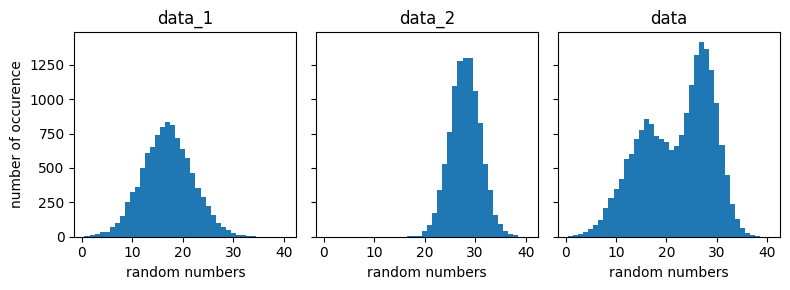

In [51]:
# run cell to visualize data
bins = np.arange(start=0.5, stop=41.5, step=1).tolist()
fig, axs = plt.subplots(ncols=3, figsize=(8, 3), sharey=True, sharex=True)
_ = axs[0].hist(data_1, bins=bins)
_ = axs[1].hist(data_2, bins=bins)
_ = axs[2].hist(data, bins=bins)
for ax in axs: ax.set_xlabel("random numbers")
for ax, t in zip(axs, ["data_1", "data_2", "data"]): ax.set_title(t)
axs[0].set_ylabel("number of occurence")
fig.tight_layout()

##### 1.2 Calculate the mean, median, and mode of ``data`` and store the values in ``data_mean``, ``data_median``, and ``data_mode``. Make sure that ``data_mode`` is of type int:

**Hint**: You can us either ``numpy`` or ``scipy.stats`` functions for that.

In [72]:
### BEGIN SOLUTION
data_mean = np.mean(data)
data_median = np.median(data)
data_mode, _ = stats.mode(data, keepdims=True)
data_mode = int(data_mode)
### END SOLUTION

In [75]:
# run test to check your implementation
assert type(data_mode) == int
assert data_mean > 15 and data_median > 15 and data_mode > 15, "Check the calculation"

##### 1.3

In [56]:
data_corrected = data.copy()

### BEGIN SOLUTION
data_zscore = stats.zscore(data)
data_zscore_exclude = np.abs(data_zscore) > 2
data_corrected[data_zscore_exclude] = data_median
### END SOLUTION

In [62]:
assert np.min(data_corrected) > np.min(data) and np.max(data_corrected) < np.max(data), "Check whether you replaced outliers on both sides of the mean"
assert np.sum(data_corrected == data_median) > 1000, "Check if you replace all outliers with data_median"

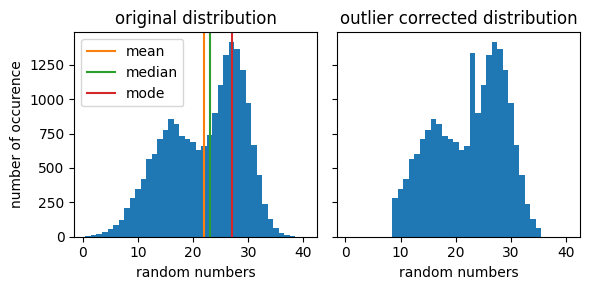

In [65]:
# run cell to visualize both distributions
bins = np.arange(start=0.5, stop=41.5, step=1).tolist()
fig, axs = plt.subplots(ncols=2, figsize=(6, 3), sharey=True, sharex=True)
_ = axs[0].hist(data, bins=bins)
axs[0].set_title("original distribution")
axs[0].set_xlabel("random numbers")
axs[0].set_ylabel("number of occurence")
for val, key, c in zip([data_mean, data_median, data_mode], ["mean", "median", "mode"], ["tab:orange", "tab:green", "tab:red"]):
    axs[0].axvline(val, color=c, label=key)
axs[0].legend()
_ = axs[1].hist(data_corrected, bins=bins)
axs[1].set_title("outlier corrected distribution")
axs[1].set_xlabel("random numbers")
fig.tight_layout()

#### XX. Questionnaire
* Different type of statistical analysis (t-test dependent?)

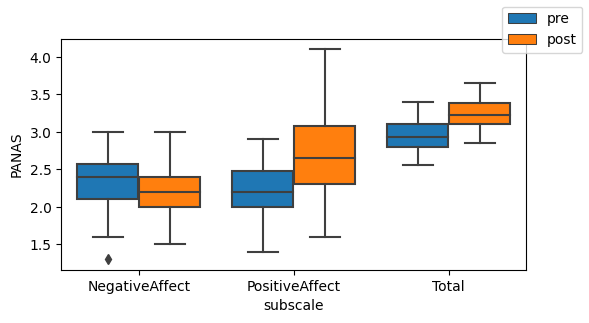

In [37]:
# run cell to load and visualize data
data_panas = bp.example_data.get_stats_example()
fig, ax = plt.subplots(figsize=(6, 3))
bp.plotting.feature_boxplot(
    data=data_panas, x="subscale", y="PANAS", hue="time", hue_order=["pre", "post"], ax=ax
);

In [43]:
# run cell to show data_panas
data_analysis = data_panas.reset_index()
data_analysis.head()

,subject,subscale,time,PANAS
0,Vp01,NegativeAffect,post,2.2
1,Vp01,NegativeAffect,pre,2.2
2,Vp01,PositiveAffect,post,2.8
3,Vp01,PositiveAffect,pre,2.4
4,Vp01,Total,post,3.3


##### XX.X

In [44]:
### BEGIN SOLUTION
results_statistics = pd.DataFrame()
for key, data in data_analysis.groupby("subscale"):
    res = pg.pairwise_tests(data=data, dv="PANAS", within="time", subject="subject")
    res["subscale"] = key
    res = res.set_index("subscale")
    results_statistics = pd.concat([results_statistics, res], axis=0)
results_statistics
### END SOLUTION

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
subscale,,,,,,,,,,,
NegativeAffect,time,post,pre,True,True,-1.335466,37.0,two-sided,1.898819e-01,0.396,-0.216180
PositiveAffect,time,post,pre,True,True,6.025414,37.0,two-sided,5.800427e-07,2.85e+04,0.974708
Total,time,post,pre,True,True,7.488770,37.0,two-sided,6.391415e-09,1.968e+06,1.386081


In [40]:
# run tests to check your implementation
assert results_statistics.shape[0] == 3
assert results_statistics["Paired"].sum() == 3
assert list(results_statistics["Contrast"])[0] == "time" and list(results_statistics["A"])[0] == "post" and list(results_statistics["B"])[0] == "pre"

#### XX. Cortisol Analysis
* Same study data as last time 
* but this time cortisol data

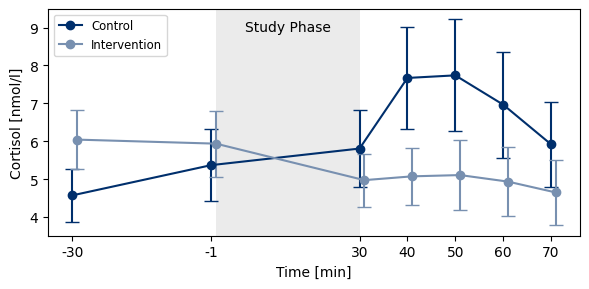

In [46]:
data_cortisol = bp.example_data.get_saliva_example()
sample_times = [-30, -1, 30, 40, 50, 60, 70]
fig, ax = plt.subplots(figsize=(6, 3))
bp.protocols.plotting.saliva_plot(
    data=data_cortisol, saliva_type="cortisol", sample_times=sample_times, test_times=[0, 30], sample_times_absolute=True,
    test_title="Study Phase", ax=ax,
);

In [45]:
auc = bp.saliva.auc(
    data_cortisol, saliva_type="cortisol", sample_times=sample_times, compute_auc_post=True, remove_s0=True
)
max_inc = bp.saliva.max_increase(data_cortisol, saliva_type="cortisol", remove_s0=True)
slope = bp.saliva.slope(data_cortisol, sample_idx=[1, 4], sample_times=sample_times, saliva_type="cortisol")

cort_features = pd.concat([auc, max_inc, slope], axis=1)
cort_features = bp.saliva.utils.saliva_feature_wide_to_long(cort_features, saliva_type="cortisol")
data_analysis = cort_features.reset_index()
data_analysis.head()

,condition,subject,saliva_feature,cortisol
0,Control,Vp03,auc_g,870.418075
1,Control,Vp03,auc_i,-72.035925
2,Control,Vp03,auc_i_post,104.057250
3,Control,Vp03,max_inc,0.956000
4,Control,Vp03,slope14,0.013971


##### XX.X Preparatory Analysis: Normality Check
* Analyses applied to the data before performing the actual statistical analysis
* Testing whether a random sample comes from a normal distribution

In [23]:
### BEGIN SOLUTION
results_normality = pd.DataFrame()
for key, data in data_analysis.groupby("condition"):
    res = pg.normality(data=data, dv="cortisol", group="saliva_feature", method="shapiro", alpha=0.05)
    res["condition"] = key
    res = res.reset_index().set_index(["saliva_feature", "condition"])
    results_normality = pd.concat([results_normality, res], axis=0)
results_normality = results_normality.sort_index()
results_normality
### END SOLUTION

W      pval  normal
saliva_feature condition                               
auc_g          Control       0.898948  0.129354    True
               Intervention  0.895831  0.117228    True
auc_i          Control       0.836432  0.019092   False
               Intervention  0.950165  0.600787    True
auc_i_post     Control       0.852757  0.030958   False
               Intervention  0.941383  0.475055    True
max_inc        Control       0.853697  0.031845   False
               Intervention  0.983297  0.991731    True
slope14        Control       0.857235  0.035429   False
               Intervention  0.965331  0.833049    True

In [ ]:
assert results_normality.shape[0] == 10, "Check if you performed and stored the results for all condition-saliva feature combinations"
assert list(results_normality.columns) == ["W", "pval", "normal"], "Check if you performed the right analysis"
assert type(results_normality.index) == pd.MultiIndex and list(results_normality.index.names) == ["saliva_feature", "condition"], "Check if you set saliva feature and condition as index"
assert list(results_normality.index.get_level_values(1)) == ["Control", "Intervention"] * 5, "Check if you sorted your index"
assert results_normality["normal"].to_list() == [True, True, False, True, False, True, False, True, False, True], "Check if you set the parameters correctly"

##### XX.X Preparatory Analysis: Homoscedasticity Check
Testing the equality of variances

In [21]:
### BEGIN SOLUTION
results_variance = pd.DataFrame()
for key, data in data_analysis.groupby("saliva_feature"):
    res = pg.homoscedasticity(data=data, dv="cortisol", group="condition")
    res["saliva_feature"] = key
    res = res.reset_index(drop=True).set_index("saliva_feature")
    results_variance = pd.concat([results_variance, res], axis=0)
results_variance
### END SOLUTION

,W,pval,equal_var
saliva_feature,,,
auc_g,1.972959,0.172945,True
auc_i,0.999657,0.327368,True
auc_i_post,0.254504,0.618522,True
max_inc,1.946181,0.175776,True
slope14,0.782662,0.385106,True


In [ ]:
assert results_variance.shape[0] == 5, "Check if you performed the test for all 5 saliva features"
assert list(results_variance.columns) == ["W", "pval", "equal_var"], "Check if you performed the right analysis"
assert type(results_variance.index) == pd.Index and list(results_variance.index.names) ==["saliva_feature"], "Check if you set only saliva_feature as index"
assert list(results_variance.index) == ["auc_g", "auc_i", "auc_i_post", "max_inc", "slope14"], "Check if you set the index correctly"
assert list(results_variance["equal_var"]) == [True] * 5, "Check if you set the parameters correctly"

##### XX.X Statistical Test: Pairwise T-tests

In [22]:
### BEGIN SOLUTION
results_statistics = pd.DataFrame()
for key, data in data_analysis.groupby("saliva_feature"):
    res = pg.pairwise_tests(data=data, dv="cortisol", between="condition")
    res["saliva_feature"] = key
    res = res.reset_index(drop=True).set_index("saliva_feature")
    results_statistics = pd.concat([results_statistics, res], axis=0)
results_statistics
### END SOLUTION

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
saliva_feature,,,,,,,,,,,
auc_g,condition,Control,Intervention,False,True,0.934452,24.0,two-sided,0.359378,0.5,0.354948
auc_i,condition,Control,Intervention,False,True,1.970669,24.0,two-sided,0.060402,1.439,0.748551
auc_i_post,condition,Control,Intervention,False,True,1.910518,24.0,two-sided,0.068085,1.33,0.725703
max_inc,condition,Control,Intervention,False,True,2.169696,24.0,two-sided,0.040155,1.896,0.824150
slope14,condition,Control,Intervention,False,True,2.201028,24.0,two-sided,0.037595,1.984,0.836051


In [ ]:
assert results_statistics.shape[0] == 5, "Check if you performed the test for all the saliva features"
assert results_statistics.loc["auc_g", "p-unc"].round(3) == 0.359, "Check if you performed the right type of test"
assert results_statistics.loc["auc_i", "p-unc"].round(3) == 0.06, "Check if you performed the right type of test"
assert results_statistics.loc["auc_i_post", "p-unc"].round(3) == 0.068, "Check if you performed the right type of test"
assert results_statistics.loc["max_inc", "p-unc"].round(3) == 0.04, "Check if you performed the right type of test"
assert results_statistics.loc["slope14", "p-unc"].round(3) == 0.038, "Check if you performed the right type of test"